# VIDEO GAMES SALES DATASET

>Importing Libraries

This dataset contains comprehensive information about video games released across various platforms, including details such as game titles, release years, genres, publishers, and developers. It also includes regional and global sales figures, critic and user review scores, and ESRB ratings. You can use this dataset to analyze trends in game popularity across regions, understand how different genres perform in various markets, and examine the relationship between critic scores, user ratings, and sales performance.

The dataset is valuable for discovering insights into the gaming industry—such as which publishers dominate globally, how game ratings influence customer interest, or how certain platforms perform over time. It can also help identify patterns in successful game releases, evaluate consumer preferences, and highlight opportunities for game developers and distributors to optimize marketing or development strategies.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import matplotlib.gridspec as gridspec
plt.style.use('seaborn-v0_8-whitegrid')




##### Importing the dataset

In [2]:
df=pd.read_csv("Video_Games.csv")

##### First Five rows

In [3]:
print(df)

                                Name Platform  Year_of_Release         Genre  \
0                         Wii Sports      Wii           2006.0        Sports   
1                  Super Mario Bros.      NES           1985.0      Platform   
2                     Mario Kart Wii      Wii           2008.0        Racing   
3                  Wii Sports Resort      Wii           2009.0        Sports   
4           Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   
...                              ...      ...              ...           ...   
16714  Samurai Warriors: Sanada Maru      PS3           2016.0        Action   
16715               LMA Manager 2007     X360           2006.0        Sports   
16716        Haitaka no Psychedelica      PSV           2016.0     Adventure   
16717               Spirits & Spells      GBA           2003.0      Platform   
16718            Winning Post 8 2016      PSV           2016.0    Simulation   

          Publisher  NA_Sales  EU_Sales

##### Last five rows

In [4]:
print(df.tail(5))

                                Name Platform  Year_of_Release       Genre  \
16714  Samurai Warriors: Sanada Maru      PS3           2016.0      Action   
16715               LMA Manager 2007     X360           2006.0      Sports   
16716        Haitaka no Psychedelica      PSV           2016.0   Adventure   
16717               Spirits & Spells      GBA           2003.0    Platform   
16718            Winning Post 8 2016      PSV           2016.0  Simulation   

          Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  \
16714    Tecmo Koei      0.00      0.00      0.01          0.0          0.01   
16715   Codemasters      0.00      0.01      0.00          0.0          0.01   
16716  Idea Factory      0.00      0.00      0.01          0.0          0.01   
16717       Wanadoo      0.01      0.00      0.00          0.0          0.01   
16718    Tecmo Koei      0.00      0.00      0.01          0.0          0.01   

       Critic_Score  Critic_Count User_Score  User

##### Checking datatypes

In [5]:
print(df.dtypes)

Name                object
Platform            object
Year_of_Release    float64
Genre               object
Publisher           object
NA_Sales           float64
EU_Sales           float64
JP_Sales           float64
Other_Sales        float64
Global_Sales       float64
Critic_Score       float64
Critic_Count       float64
User_Score          object
User_Count         float64
Developer           object
Rating              object
dtype: object


##### Checking the missing values 

In [6]:
print(df.isna().sum())
print('\n',"Toatal Count of missing value:",df.isna().sum().sum())

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

 Toatal Count of missing value: 46716


#### Plotting missing values for better view ####

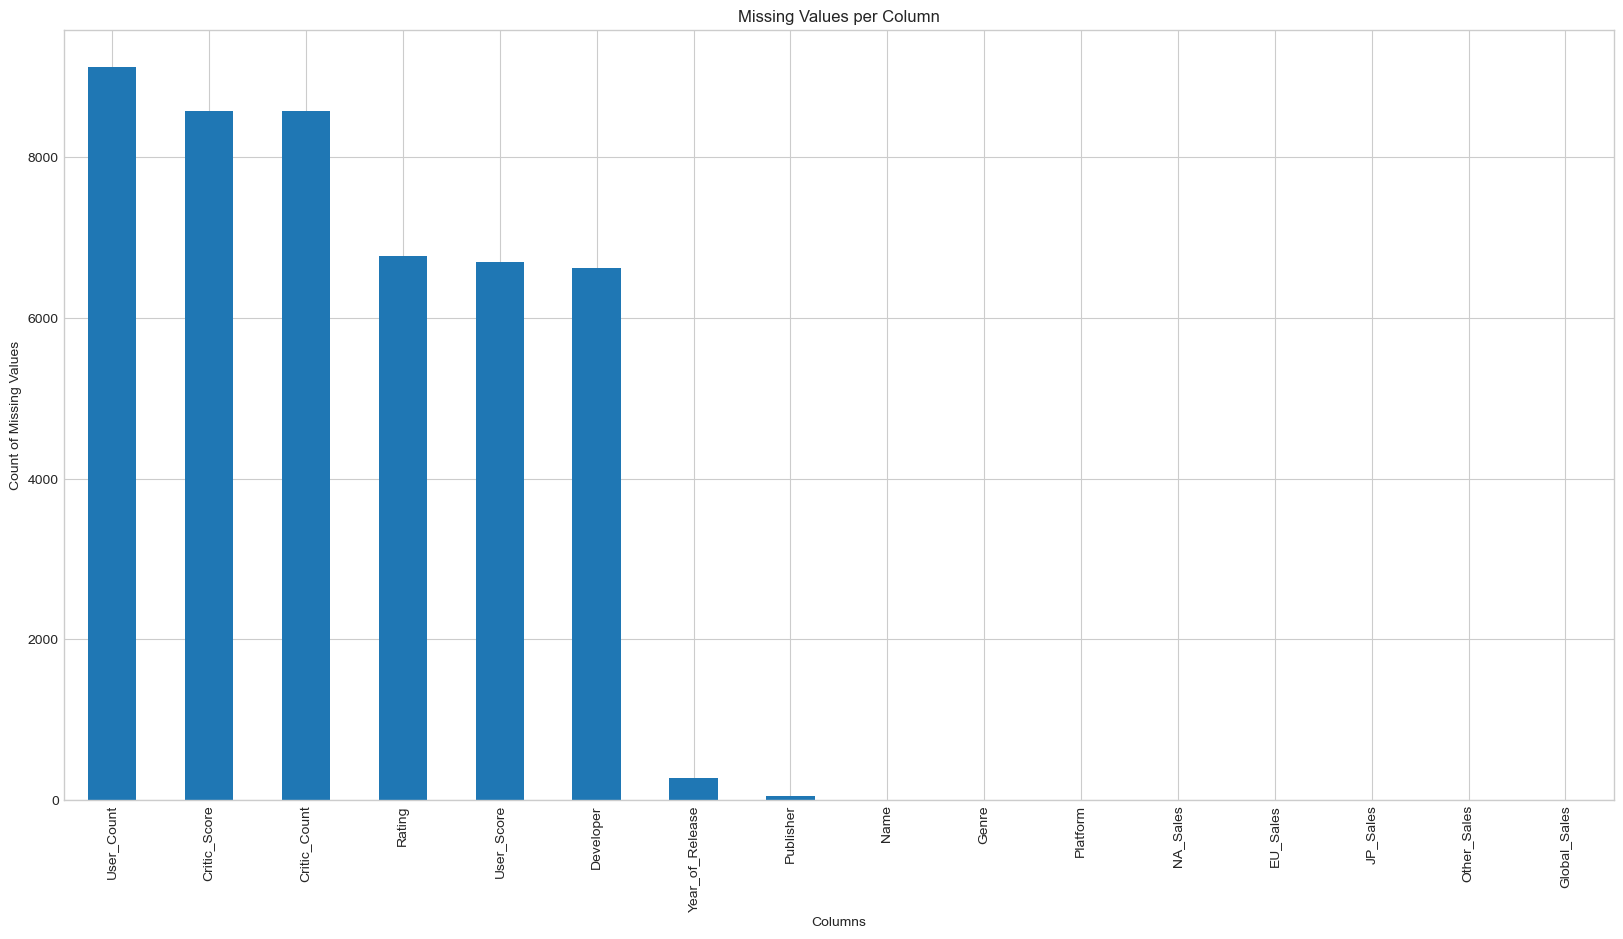

In [7]:
missing = df.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(20,10))
missing.plot(kind='bar')
plt.title("Missing Values per Column")
plt.ylabel("Count of Missing Values")
plt.xlabel("Columns")
plt.show()

##### Describing the data 

In [8]:
print(df.describe())

       Year_of_Release      NA_Sales      EU_Sales      JP_Sales  \
count     16450.000000  16719.000000  16719.000000  16719.000000   
mean       2006.487356      0.263330      0.145025      0.077602   
std           5.878995      0.813514      0.503283      0.308818   
min        1980.000000      0.000000      0.000000      0.000000   
25%        2003.000000      0.000000      0.000000      0.000000   
50%        2007.000000      0.080000      0.020000      0.000000   
75%        2010.000000      0.240000      0.110000      0.040000   
max        2020.000000     41.360000     28.960000     10.220000   

        Other_Sales  Global_Sales  Critic_Score  Critic_Count    User_Count  
count  16719.000000  16719.000000   8137.000000   8137.000000   7590.000000  
mean       0.047332      0.533543     68.967679     26.360821    162.229908  
std        0.186710      1.547935     13.938165     18.980495    561.282326  
min        0.000000      0.010000     13.000000      3.000000      4.000000

##### Info about the data

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB
None


#### Checking for duplicates ####

In [10]:
print(df.duplicated())

0        False
1        False
2        False
3        False
4        False
         ...  
16714    False
16715    False
16716    False
16717    False
16718    False
Length: 16719, dtype: bool


#### Column names

In [11]:
print(df.columns)

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='object')


##### Renaming the columns

In [12]:
df.rename(columns={
    "NA_Sales":"North_America_Sales",
    "EU_Sales":"Europe_Sales",
    "JP_Sales":"Japan_Sales",
    "Name":"Game_Name"
},inplace=True)
print(df.columns)


Index(['Game_Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher',
       'North_America_Sales', 'Europe_Sales', 'Japan_Sales', 'Other_Sales',
       'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score',
       'User_Count', 'Developer', 'Rating'],
      dtype='object')


## Data Cleaning and Preprocessing

##### Removing missing year values #####

In [13]:
df_year = df.dropna(subset=['Year_of_Release'])
print(f"Dataset after removing missing year values: {df_year.shape}")
print(f"Rows removed: {len(df) - len(df_year)}")
print(df_year.head())

Dataset after removing missing year values: (16450, 16)
Rows removed: 269
                  Game_Name Platform  Year_of_Release         Genre Publisher  \
0                Wii Sports      Wii           2006.0        Sports  Nintendo   
1         Super Mario Bros.      NES           1985.0      Platform  Nintendo   
2            Mario Kart Wii      Wii           2008.0        Racing  Nintendo   
3         Wii Sports Resort      Wii           2009.0        Sports  Nintendo   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing  Nintendo   

   North_America_Sales  Europe_Sales  Japan_Sales  Other_Sales  Global_Sales  \
0                41.36         28.96         3.77         8.45         82.53   
1                29.08          3.58         6.81         0.77         40.24   
2                15.68         12.76         3.79         3.29         35.52   
3                15.61         10.93         3.28         2.95         32.77   
4                11.27          8.89   

##### Replacing misssing user score with median 

In [14]:
df['User_Score'] = df['User_Score'].replace('tbd', np.nan)

# Convert to numeric
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')

# Fill missing with median
df['User_Score'] = df['User_Score'].fillna(df['User_Score'].median())
print("User_Score - Missing values replaced with median")
print(f"Median User_Score: {df['User_Score'].median():.2f}")
print(df[['Game_Name', 'User_Score']].head())

User_Score - Missing values replaced with median
Median User_Score: 7.50
                  Game_Name  User_Score
0                Wii Sports         8.0
1         Super Mario Bros.         7.5
2            Mario Kart Wii         8.3
3         Wii Sports Resort         8.0
4  Pokemon Red/Pokemon Blue         7.5


##### Replacing misssing critic score with median 

In [15]:
df['Critic_Score'] = df['Critic_Score'].fillna(df['Critic_Score'].median())
print("Critic_Score - Missing values replaced with median")
print(f"Median Critic_Score: {df['Critic_Score'].median():.2f}")
print(df[['Game_Name', 'Critic_Score']].head())

Critic_Score - Missing values replaced with median
Median Critic_Score: 71.00
                  Game_Name  Critic_Score
0                Wii Sports          76.0
1         Super Mario Bros.          71.0
2            Mario Kart Wii          82.0
3         Wii Sports Resort          80.0
4  Pokemon Red/Pokemon Blue          71.0


##### Fill critic count with zeroes

In [16]:
df['Critic_Count'] = df['Critic_Count'].fillna(0)
print("Critic_Count - Missing values filled with 0")
print(f"Total missing Critic_Count replaced: {(df['Critic_Count'] == 0).sum()}")
print(df[['Game_Name', 'Critic_Count']].head())

Critic_Count - Missing values filled with 0
Total missing Critic_Count replaced: 8582
                  Game_Name  Critic_Count
0                Wii Sports          51.0
1         Super Mario Bros.           0.0
2            Mario Kart Wii          73.0
3         Wii Sports Resort          73.0
4  Pokemon Red/Pokemon Blue           0.0


##### Fill user count with zeroes

In [17]:
df['User_Count'] = df['User_Count'].fillna(0)
print("User_Count - Missing values filled with 0")
print(f"Total User_Count records: {len(df)}")
print(f"Non-zero User_Count: {(df['User_Count'] > 0).sum()}")
print(df[['Game_Name', 'User_Count']].head())

User_Count - Missing values filled with 0
Total User_Count records: 16719
Non-zero User_Count: 7590
                  Game_Name  User_Count
0                Wii Sports       322.0
1         Super Mario Bros.         0.0
2            Mario Kart Wii       709.0
3         Wii Sports Resort       192.0
4  Pokemon Red/Pokemon Blue         0.0


##### Convert year of release to integer

In [18]:
df_year = df.dropna(subset=['Year_of_Release'])
df_year['Year_of_Release'] = df_year['Year_of_Release'].astype(int)
print("Year_of_Release converted to integer")
print(f"Data shape: {df_year.shape}")
print(f"Year range: {df_year['Year_of_Release'].min()} - {df_year['Year_of_Release'].max()}")
print(df_year[['Game_Name', 'Year_of_Release']].head())

Year_of_Release converted to integer
Data shape: (16450, 16)
Year range: 1980 - 2020
                  Game_Name  Year_of_Release
0                Wii Sports             2006
1         Super Mario Bros.             1985
2            Mario Kart Wii             2008
3         Wii Sports Resort             2009
4  Pokemon Red/Pokemon Blue             1996


In [19]:
df_year.dtypes

Game_Name               object
Platform                object
Year_of_Release          int32
Genre                   object
Publisher               object
North_America_Sales    float64
Europe_Sales           float64
Japan_Sales            float64
Other_Sales            float64
Global_Sales           float64
Critic_Score           float64
Critic_Count           float64
User_Score             float64
User_Count             float64
Developer               object
Rating                  object
dtype: object

##### Sort by year

In [20]:
df_year = df_year.sort_values('Year_of_Release')
print("Data sorted by Year_of_Release")
print(f"First year: {df_year['Year_of_Release'].min()}")
print(f"Last year: {df_year['Year_of_Release'].max()}")
print(df_year[['Game_Name', 'Year_of_Release']].head())

Data sorted by Year_of_Release
First year: 1980
Last year: 2020
            Game_Name  Year_of_Release
262         Asteroids             1980
5360          Freeway             1980
546   Missile Command             1980
2650           Boxing             1980
4019       Ice Hockey             1980


## Feature Engineering

##### Create a Decade feature 

In [21]:
df_year['Decade'] = (df_year['Year_of_Release'] // 10) * 10
print("Decade feature created")
print(f"Unique decades: {sorted(df_year['Decade'].unique())}")
print(df_year[['Game_Name', 'Year_of_Release', 'Decade']].head())

Decade feature created
Unique decades: [1980, 1990, 2000, 2010, 2020]
            Game_Name  Year_of_Release  Decade
262         Asteroids             1980    1980
5360          Freeway             1980    1980
546   Missile Command             1980    1980
2650           Boxing             1980    1980
4019       Ice Hockey             1980    1980


##### Regional domiance feature

In [22]:
df_year['Top_Region'] = df_year[
    ['North_America_Sales', 'Europe_Sales', 'Japan_Sales', 'Other_Sales']
].idxmax(axis=1)
print(df_year[['Game_Name', 'Year_of_Release', 'Top_Region']].head(10))

            Game_Name  Year_of_Release           Top_Region
262         Asteroids             1980  North_America_Sales
5360          Freeway             1980  North_America_Sales
546   Missile Command             1980  North_America_Sales
2650           Boxing             1980  North_America_Sales
4019       Ice Hockey             1980  North_America_Sales
6301           Bridge             1980  North_America_Sales
1764          Kaboom!             1980  North_America_Sales
6876         Checkers             1980  North_America_Sales
1968         Defender             1980  North_America_Sales
4123       Grand Prix             1981  North_America_Sales


High / Medium / Low Sales Category

In [23]:
df['Sales_Category'] = pd.cut(
    df['Global_Sales'],
    bins=[-1, 1, 10, df['Global_Sales'].max()],
    labels=['Low', 'Medium', 'High']
)
print("Sales_Category feature created")
print(df['Sales_Category'].value_counts())
print("\nSample data:")
print(df[['Game_Name', 'Global_Sales', 'Sales_Category']].head())

Sales_Category feature created
Low       14662
Medium     1995
High         62
Name: Sales_Category, dtype: int64

Sample data:
                  Game_Name  Global_Sales Sales_Category
0                Wii Sports         82.53           High
1         Super Mario Bros.         40.24           High
2            Mario Kart Wii         35.52           High
3         Wii Sports Resort         32.77           High
4  Pokemon Red/Pokemon Blue         31.37           High


Review Availability Flag

Critic Review Availability

In [24]:
df['Has_Critic_Review'] = df['Critic_Count'].apply(lambda x: 1 if x > 0 else 0)
print("Has_Critic_Review feature created")
print(f"Games with critic reviews: {df['Has_Critic_Review'].sum()}")
print(f"Games without critic reviews: {(df['Has_Critic_Review'] == 0).sum()}")
print(df[['Game_Name', 'Critic_Count', 'Has_Critic_Review']].head())

Has_Critic_Review feature created
Games with critic reviews: 8137
Games without critic reviews: 8582
                  Game_Name  Critic_Count  Has_Critic_Review
0                Wii Sports          51.0                  1
1         Super Mario Bros.           0.0                  0
2            Mario Kart Wii          73.0                  1
3         Wii Sports Resort          73.0                  1
4  Pokemon Red/Pokemon Blue           0.0                  0


User Review Availability

In [25]:
df['Has_User_Review'] = df['User_Count'].apply(lambda x: 1 if x > 0 else 0)
print("Has_User_Review feature created")
print(f"Games with user reviews: {df['Has_User_Review'].sum()}")
print(f"Games without user reviews: {(df['Has_User_Review'] == 0).sum()}")
print(df[['Game_Name', 'User_Count', 'Has_User_Review']].head())

Has_User_Review feature created
Games with user reviews: 7590
Games without user reviews: 9129
                  Game_Name  User_Count  Has_User_Review
0                Wii Sports       322.0                1
1         Super Mario Bros.         0.0                0
2            Mario Kart Wii       709.0                1
3         Wii Sports Resort       192.0                1
4  Pokemon Red/Pokemon Blue         0.0                0


Any Review (Critic OR User)

In [26]:
df['Has_Any_Review'] = (
    (df['Critic_Count'] > 0) | (df['User_Count'] > 0)
).astype(int)
print("Has_Any_Review feature created")
print(f"Games with any review (Critic OR User): {df['Has_Any_Review'].sum()}")
print(f"Games without any review: {(df['Has_Any_Review'] == 0).sum()}")
print(df[['Game_Name', 'Has_Critic_Review', 'Has_User_Review', 'Has_Any_Review']].head())

Has_Any_Review feature created
Games with any review (Critic OR User): 8710
Games without any review: 8009
                  Game_Name  Has_Critic_Review  Has_User_Review  \
0                Wii Sports                  1                1   
1         Super Mario Bros.                  0                0   
2            Mario Kart Wii                  1                1   
3         Wii Sports Resort                  1                1   
4  Pokemon Red/Pokemon Blue                  0                0   

   Has_Any_Review  
0               1  
1               0  
2               1  
3               1  
4               0  


Compare sales

In [27]:
df.groupby('Has_Any_Review')['Global_Sales'].mean()


Has_Any_Review
0    0.385092
1    0.670046
Name: Global_Sales, dtype: float64

Bar plot

<Axes: >

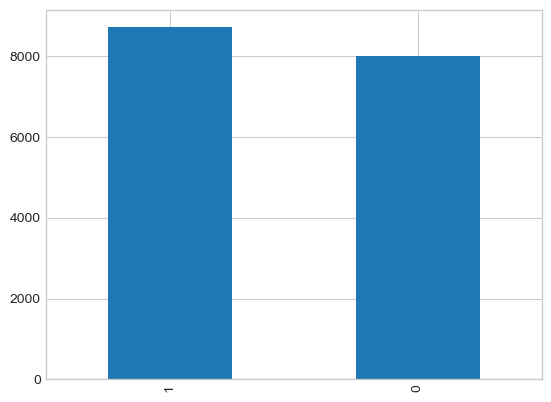

In [28]:
df['Has_Any_Review'].value_counts().plot(kind='bar')


Sales distribution

<Axes: title={'center': 'Global_Sales'}, xlabel='Has_Any_Review'>

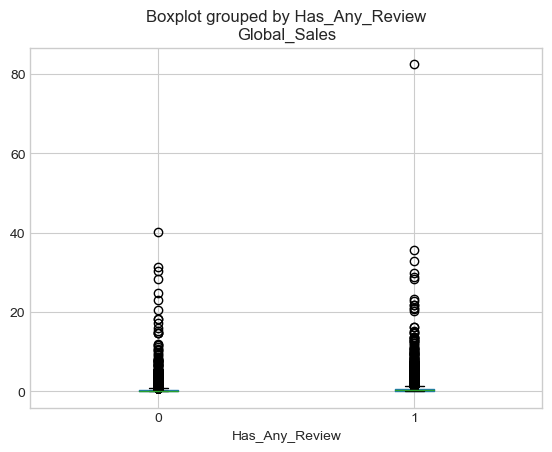

In [29]:
df.boxplot(column='Global_Sales', by='Has_Any_Review')


#### QUSTIONS TO WORK WITH THIS DATASET 

1.How have global video game sales changed over time?

2.Which platforms have generated the highest total global sales?

3.Which genres are the most profitable globally?

4.How do sales differ across regions (NA, EU, JP, Other)?

5️.Which publishers have consistently high global sales?

6️.Is there a relationship between critic score and global sales?

7.Do games with more user reviews sell better?

8️.Which game ratings (E, T, M) generate the highest sales?

9️.Are newer games selling more than older games?

10.What characteristics do top-selling games share?

#### 1.How have global video game sales changed over time?

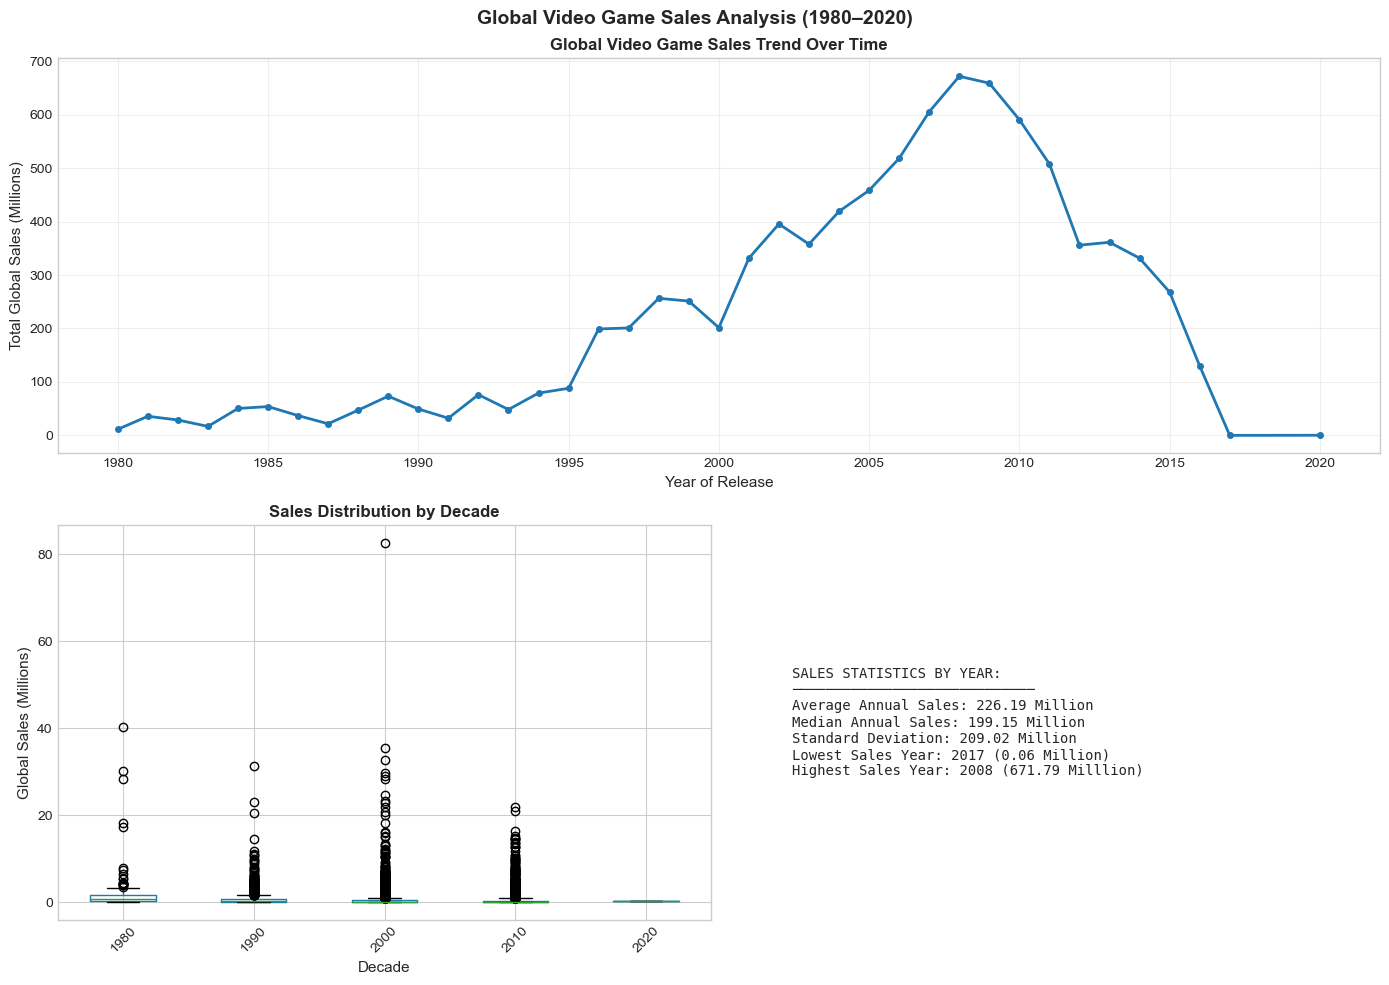


YEARLY SALES STATISTICS
Mean Global Sales per Year: $226.19M
Median Global Sales per Year: $199.15M
Std Deviation: $209.02M
Peak Year: 2008 with $671.79M


In [30]:


df_year = df.dropna(subset=['Year_of_Release']).copy()
df_year['Year_of_Release'] = df_year['Year_of_Release'].astype(int)
df_year['Decade'] = (df_year['Year_of_Release'] // 10) * 10

sales_by_year = df_year.groupby('Year_of_Release')['Global_Sales'].sum().sort_index()


# Create figure with gridspec for multiple subplots
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

plt.style.use('seaborn-v0_8-whitegrid')


# Line plot
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(sales_by_year.index, sales_by_year.values, marker='o', linewidth=2, markersize=4)
ax1.set_xlabel("Year of Release", fontsize=11)
ax1.set_ylabel("Total Global Sales (Millions)", fontsize=11)
ax1.set_title("Global Video Game Sales Trend Over Time", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Box plot
ax2 = fig.add_subplot(gs[1, 0])
df_year.boxplot(column='Global_Sales', by='Decade', ax=ax2)
ax2.set_xlabel("Decade", fontsize=11)
ax2.set_ylabel("Global Sales (Millions)", fontsize=11)
ax2.set_title("Sales Distribution by Decade", fontsize=12, fontweight='bold')
plt.sca(ax2)
plt.xticks(rotation=45)
fig.suptitle("Global Video Game Sales Analysis (1980–2020)", 
             fontsize=14, fontweight='bold')
# Statistics
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
stats_text = f"""
SALES STATISTICS BY YEAR:
─────────────────────────────
Average Annual Sales: {sales_by_year.mean():.2f} Million
Median Annual Sales: {sales_by_year.median():.2f} Million
Standard Deviation: {sales_by_year.std():.2f} Million
Lowest Sales Year: {sales_by_year.idxmin()} ({sales_by_year.min():.2f} Million)
Highest Sales Year: {sales_by_year.idxmax()} ({sales_by_year.max():.2f} Milllion)
"""
ax3.text(0.1, 0.5, stats_text, fontsize=10, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()

# Detailed statistics
print("\n" + "="*50)
print("YEARLY SALES STATISTICS")
print("="*50)
print(f"Mean Global Sales per Year: ${sales_by_year.mean():.2f}M")
print(f"Median Global Sales per Year: ${sales_by_year.median():.2f}M")
print(f"Std Deviation: ${sales_by_year.std():.2f}M")
print(f"Peak Year: {sales_by_year.idxmax()} with ${sales_by_year.max():.2f}M")

#### 2.Which platforms have generated the highest total global sales?

In [31]:

platform_sales = (
    df.groupby('Platform')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
)

platform_sales.head(10)


Platform
PS2     1255.64
X360     971.63
PS3      939.43
Wii      908.13
DS       807.10
PS       730.68
GBA      318.50
PS4      314.23
PSP      294.30
PC       260.30
Name: Global_Sales, dtype: float64

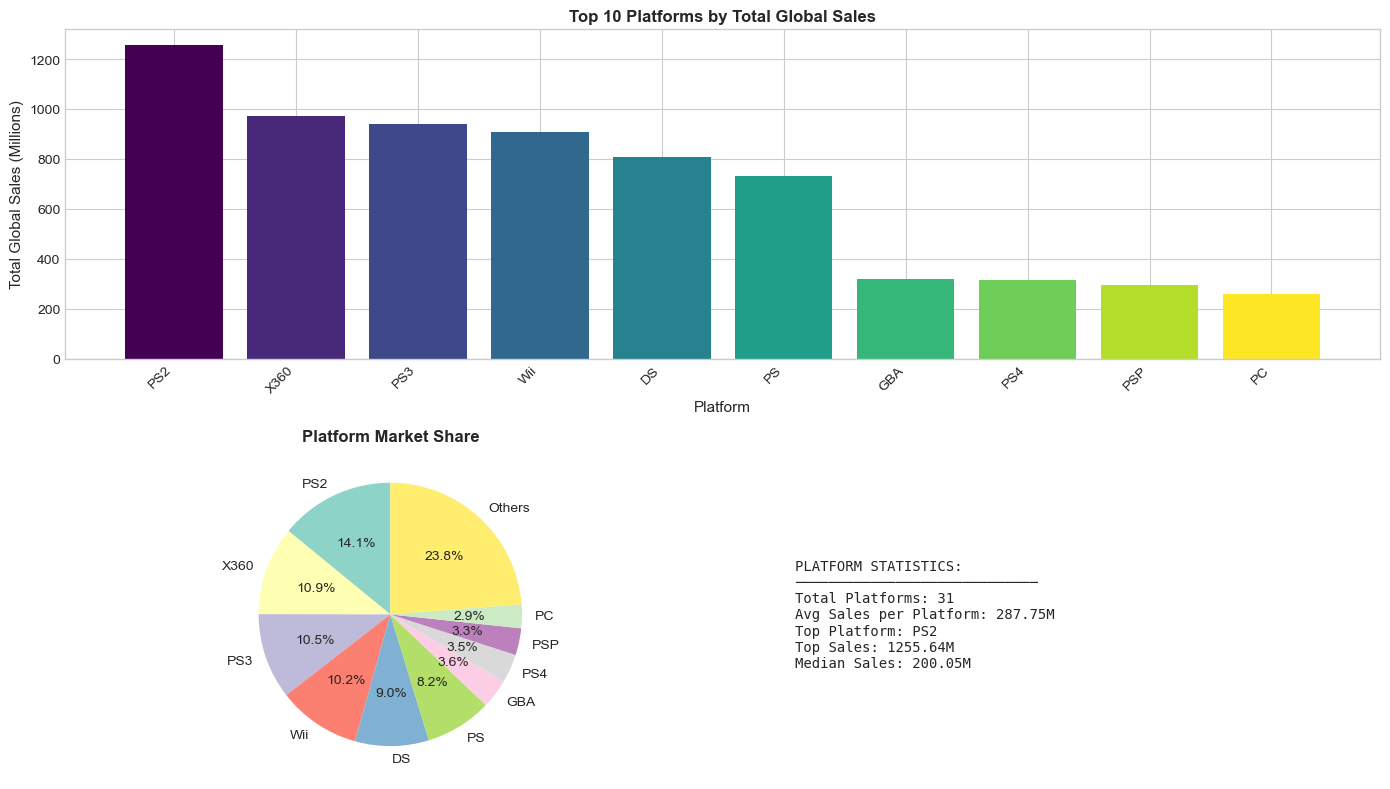


PLATFORM SALES AGGREGATES
Total Platforms: 31
Mean Sales: $287.75M
Median Sales: $200.05M
Std Dev: $348.21M

Top 5 Platforms:
Platform
PS2     1255.64
X360     971.63
PS3      939.43
Wii      908.13
DS       807.10
Name: Global_Sales, dtype: float64


In [32]:
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Bar chart
ax1 = fig.add_subplot(gs[0, :])
colors = plt.cm.viridis(np.linspace(0, 1, len(platform_sales[:10])))
ax1.bar(platform_sales.index[:10], platform_sales.values[:10], color=colors)
ax1.set_xlabel("Platform", fontsize=11)
ax1.set_ylabel("Total Global Sales (Millions)", fontsize=11)
ax1.set_title("Top 10 Platforms by Total Global Sales", fontsize=12, fontweight='bold')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Pie chart
ax2 = fig.add_subplot(gs[1, 0])
top_10_platforms = platform_sales.head(10)
other = platform_sales[10:].sum()
pie_data = list(top_10_platforms.values) + [other]
pie_labels = list(top_10_platforms.index) + ['Others']
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax2.set_title("Platform Market Share", fontsize=12, fontweight='bold')

# Statistics
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
stats_text = f"""
PLATFORM STATISTICS:
─────────────────────────────
Total Platforms: {len(platform_sales)}
Avg Sales per Platform: {platform_sales.mean():.2f}M
Top Platform: {platform_sales.idxmax()}
Top Sales: {platform_sales.max():.2f}M
Median Sales: {platform_sales.median():.2f}M
"""
ax3.text(0.1, 0.5, stats_text, fontsize=10, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()

# Aggregate statistics
print("\n" + "="*50)
print("PLATFORM SALES AGGREGATES")
print("="*50)
print(f"Total Platforms: {len(platform_sales)}")
print(f"Mean Sales: ${platform_sales.mean():.2f}M")
print(f"Median Sales: ${platform_sales.median():.2f}M")
print(f"Std Dev: ${platform_sales.std():.2f}M")
print(f"\nTop 5 Platforms:")
print(platform_sales.head())

#### 3.Which genres are the most profitable globally?

In [33]:

genre_sales = (
    df.groupby('Genre')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
)
print(genre_sales)


Genre
Action          1745.27
Sports          1332.00
Shooter         1052.94
Role-Playing     934.40
Platform         828.08
Misc             803.18
Racing           728.90
Fighting         447.48
Simulation       390.42
Puzzle           243.02
Adventure        237.69
Strategy         174.50
Name: Global_Sales, dtype: float64


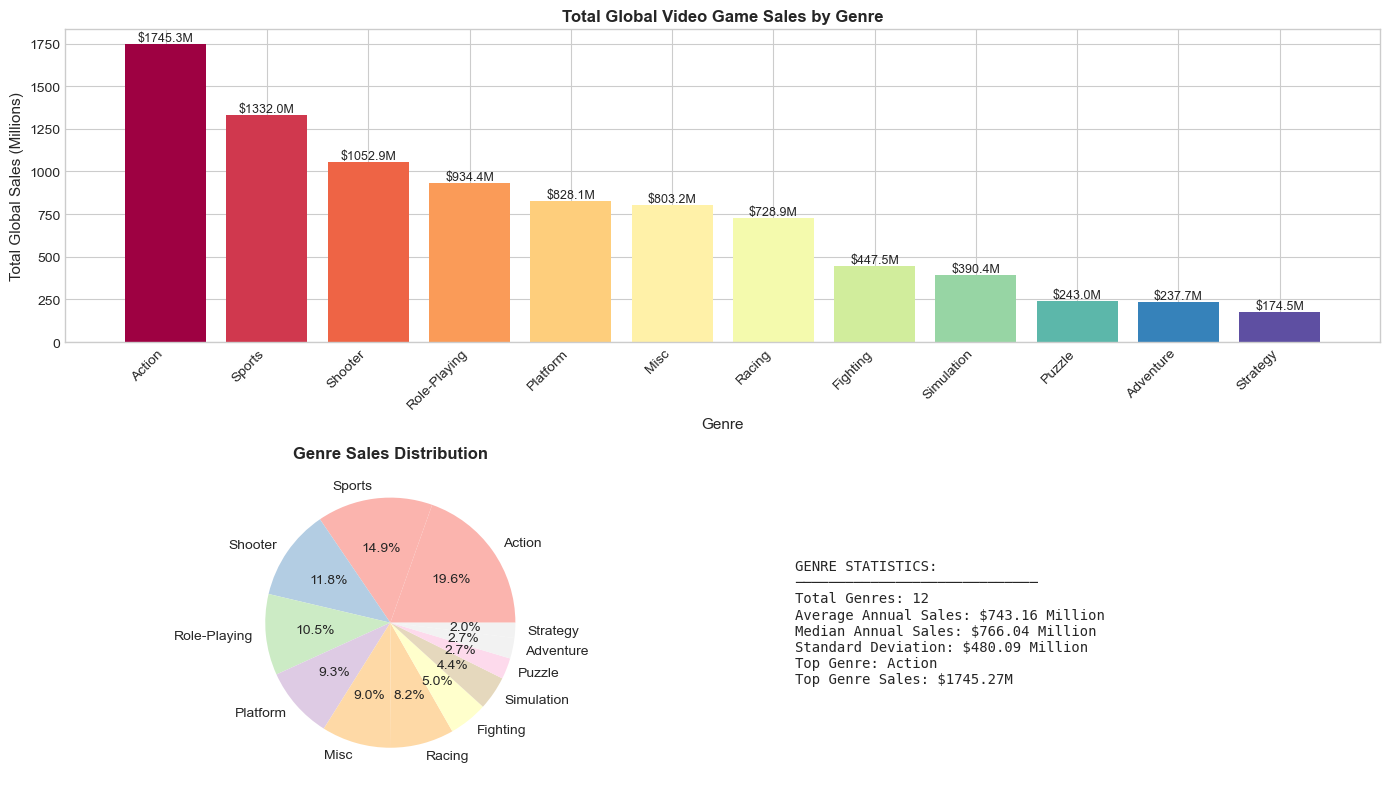


GENRE SALES AGGREGATES
Total Genres: 12
Average Annual Sales: $743.16M
Median Annual Sales: $766.04M
Standard Deviation: $480.09M

Genre Breakdown:
Genre
Action          1745.27
Sports          1332.00
Shooter         1052.94
Role-Playing     934.40
Platform         828.08
Misc             803.18
Racing           728.90
Fighting         447.48
Simulation       390.42
Puzzle           243.02
Adventure        237.69
Strategy         174.50
Name: Global_Sales, dtype: float64


In [34]:
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Bar chart
ax1 = fig.add_subplot(gs[0, :])
colors = plt.cm.Spectral(np.linspace(0, 1, len(genre_sales)))
bars = ax1.bar(genre_sales.index, genre_sales.values, color=colors)
ax1.set_xlabel("Genre", fontsize=11)
ax1.set_ylabel("Total Global Sales (Millions)", fontsize=11)
ax1.set_title("Total Global Video Game Sales by Genre", fontsize=12, fontweight='bold')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:.1f}M', ha='center', va='bottom', fontsize=9)

# Pie chart
ax2 = fig.add_subplot(gs[1, 0])
colors_pie = plt.cm.Pastel1(np.linspace(0, 1, len(genre_sales)))
ax2.pie(genre_sales.values, labels=genre_sales.index, autopct='%1.1f%%', colors=colors_pie)
ax2.set_title("Genre Sales Distribution", fontsize=12, fontweight='bold')

# Statistics
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
stats_text = f"""
GENRE STATISTICS:
─────────────────────────────
Total Genres: {len(genre_sales)}
Average Annual Sales: ${genre_sales.mean():.2f} Million
Median Annual Sales: ${genre_sales.median():.2f} Million
Standard Deviation: ${genre_sales.std():.2f} Million
Top Genre: {genre_sales.idxmax()}
Top Genre Sales: ${genre_sales.max():.2f}M
"""
ax3.text(0.1, 0.5, stats_text, fontsize=10, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()

# Statistical summary
print("\n" + "="*50)
print("GENRE SALES AGGREGATES")
print("="*50)
print(f"Total Genres: {len(genre_sales)}")
print(f"Average Annual Sales: ${genre_sales.mean():.2f}M")
print(f"Median Annual Sales: ${genre_sales.median():.2f}M")
print(f"Standard Deviation: ${genre_sales.std():.2f}M")
print(f"\nGenre Breakdown:\n{genre_sales}")

#### 4.How do sales differ across regions (NA, EU, JP, Other)?

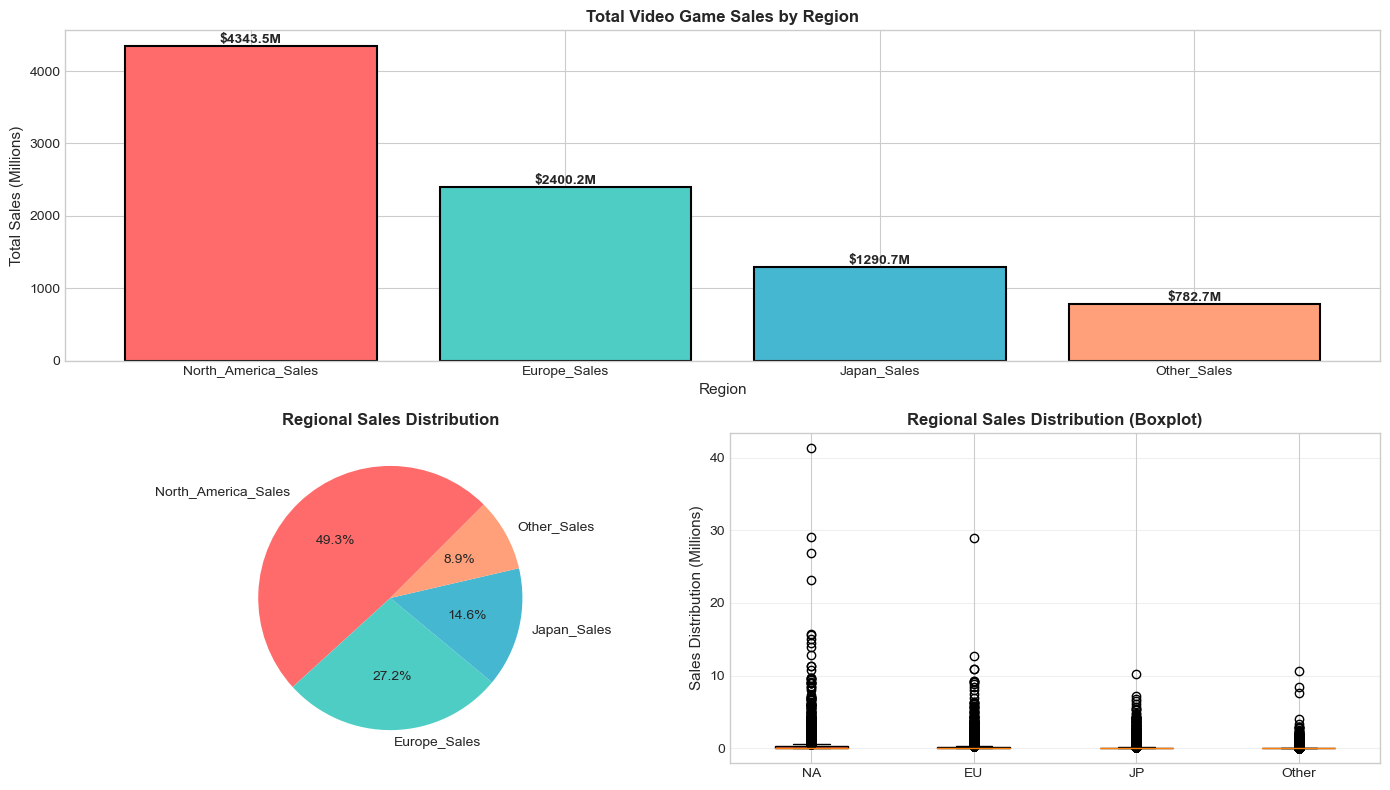


REGIONAL SALES STATISTICS

Total Sales by Region:
  North_America_Sales: $4343.47M (49.3%)
  Europe_Sales: $2400.21M (27.2%)
  Japan_Sales: $1290.73M (14.6%)
  Other_Sales: $782.73M (8.9%)

Regional Summary Statistics:
  Mean: $2204.28M
  Median: $1845.47M
  Std Dev: $1577.96M
  Max Region: North_America_Sales ($4343.47M)
  Min Region: Other_Sales ($782.73M)


In [35]:
df_year = df.dropna(subset=['Year_of_Release'])

region_sales = df_year[['North_America_Sales', 'Europe_Sales', 'Japan_Sales', 'Other_Sales']].sum()

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Bar chart
ax1 = fig.add_subplot(gs[0, :])
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = ax1.bar(region_sales.index, region_sales.values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel("Region", fontsize=11)
ax1.set_ylabel("Total Sales (Millions)", fontsize=11)
ax1.set_title("Total Video Game Sales by Region", fontsize=12, fontweight='bold')

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
ax2 = fig.add_subplot(gs[1, 0])
ax2.pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%', colors=colors, startangle=45)
ax2.set_title("Regional Sales Distribution", fontsize=12, fontweight='bold')

# Box plot comparison
ax3 = fig.add_subplot(gs[1, 1])
region_data = [df_year['North_America_Sales'], df_year['Europe_Sales'], df_year['Japan_Sales'], df_year['Other_Sales']]
bp = ax3.boxplot(region_data, labels=['NA', 'EU', 'JP', 'Other'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax3.set_ylabel("Sales Distribution (Millions)", fontsize=11)
ax3.set_title("Regional Sales Distribution (Boxplot)", fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical analysis
print("\n" + "="*60)
print("REGIONAL SALES STATISTICS")
print("="*60)
print(f"\nTotal Sales by Region:")
for region, sales in region_sales.items():
    pct = (sales / region_sales.sum()) * 100
    print(f"  {region}: ${sales:.2f}M ({pct:.1f}%)")

print(f"\nRegional Summary Statistics:")
print(f"  Mean: ${region_sales.mean():.2f}M")
print(f"  Median: ${region_sales.median():.2f}M")
print(f"  Std Dev: ${region_sales.std():.2f}M")
print(f"  Max Region: {region_sales.idxmax()} (${region_sales.max():.2f}M)")
print(f"  Min Region: {region_sales.idxmin()} (${region_sales.min():.2f}M)")

#### 5️.Which publishers have consistently high global sales?

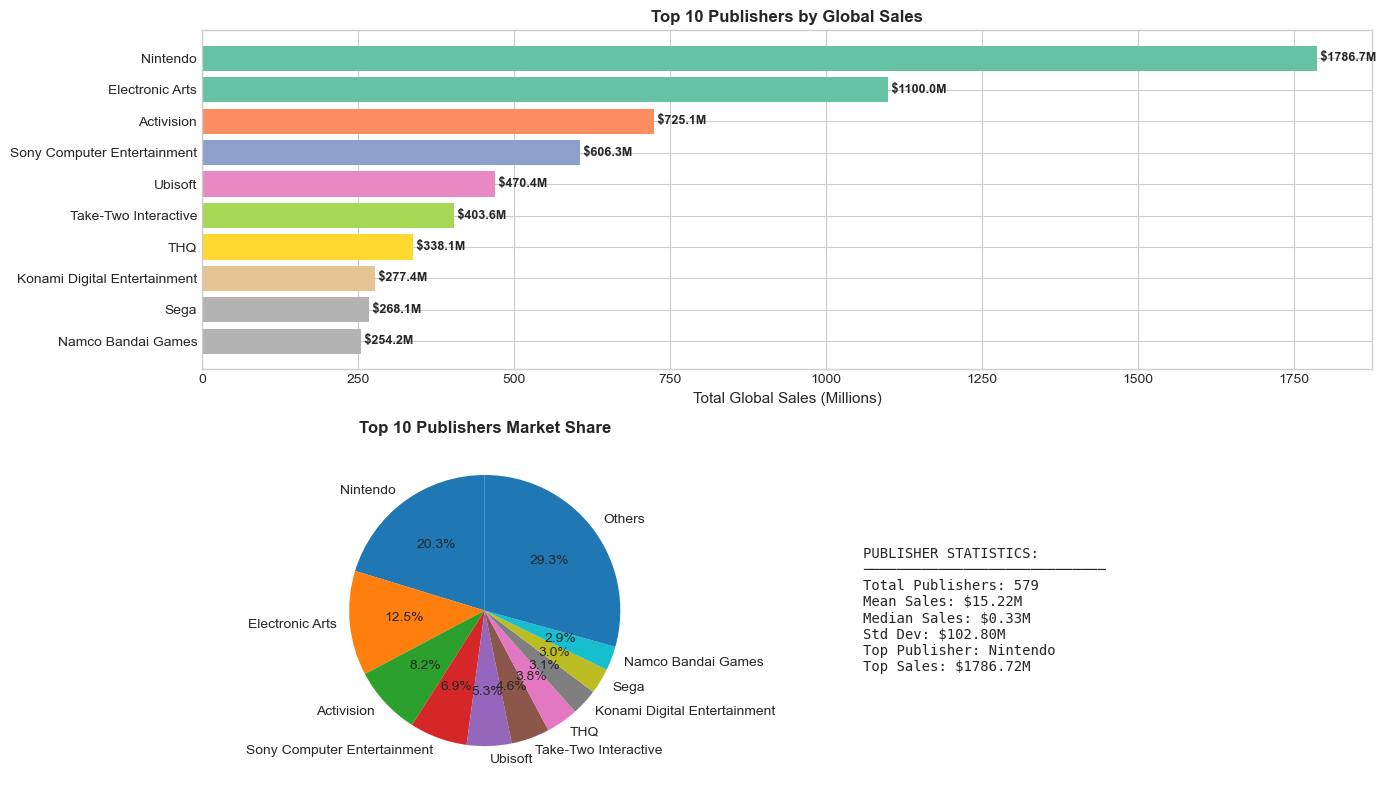


PUBLISHER SALES AGGREGATES

Total Unique Publishers: 579
Average Sales per Publisher: $15.22M
Median Sales per Publisher: $0.33M

Top 10 Publishers Details:
                                  sum      mean  count
Publisher                                             
Nintendo                      1786.72  2.552457    700
Electronic Arts               1100.05  0.818490   1344
Activision                     725.14  0.742971    976
Sony Computer Entertainment    606.27  0.883776    686
Ubisoft                        470.45  0.505860    930
Take-Two Interactive           403.58  0.958622    421
THQ                            338.11  0.474874    712
Konami Digital Entertainment   277.36  0.336194    825
Sega                           268.11  0.424897    631
Namco Bandai Games             254.19  0.271861    935


In [36]:
df_year = df.dropna(subset=['Year_of_Release'])

publisher_sales = df_year.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Bar chart
ax1 = fig.add_subplot(gs[0, :])
colors = plt.cm.Set2(np.linspace(0, 1, len(publisher_sales)))
bars = ax1.barh(publisher_sales.index, publisher_sales.values, color=colors)
ax1.set_xlabel("Total Global Sales (Millions)", fontsize=11)
ax1.set_title("Top 10 Publishers by Global Sales", fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width, bar.get_y() + bar.get_height()/2.,
            f' ${width:.1f}M', ha='left', va='center', fontsize=9, fontweight='bold')

# Pie chart
ax2 = fig.add_subplot(gs[1, 0])
other_sales = df_year.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False)[10:].sum()
pie_data = list(publisher_sales.values) + [other_sales]
pie_labels = list(publisher_sales.index) + ['Others']
ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax2.set_title("Top 10 Publishers Market Share", fontsize=12, fontweight='bold')

# Statistics
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
all_publisher_sales = df_year.groupby('Publisher')['Global_Sales'].sum()
stats_text = f"""
PUBLISHER STATISTICS:
─────────────────────────────
Total Publishers: {len(all_publisher_sales)}
Mean Sales: ${all_publisher_sales.mean():.2f}M
Median Sales: ${all_publisher_sales.median():.2f}M
Std Dev: ${all_publisher_sales.std():.2f}M
Top Publisher: {publisher_sales.idxmax()}
Top Sales: ${publisher_sales.max():.2f}M
"""
ax3.text(0.1, 0.5, stats_text, fontsize=10, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()

# Detailed statistics
print("\n" + "="*50)
print("PUBLISHER SALES AGGREGATES")
print("="*50)
all_pub_sales = df_year.groupby('Publisher')['Global_Sales'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
print(f"\nTotal Unique Publishers: {len(all_pub_sales)}")
print(f"Average Sales per Publisher: ${all_pub_sales['sum'].mean():.2f}M")
print(f"Median Sales per Publisher: ${all_pub_sales['sum'].median():.2f}M")
print(f"\nTop 10 Publishers Details:")
print(all_pub_sales.head(10))

##### 6️.Is there a relationship between critic score and global sales?

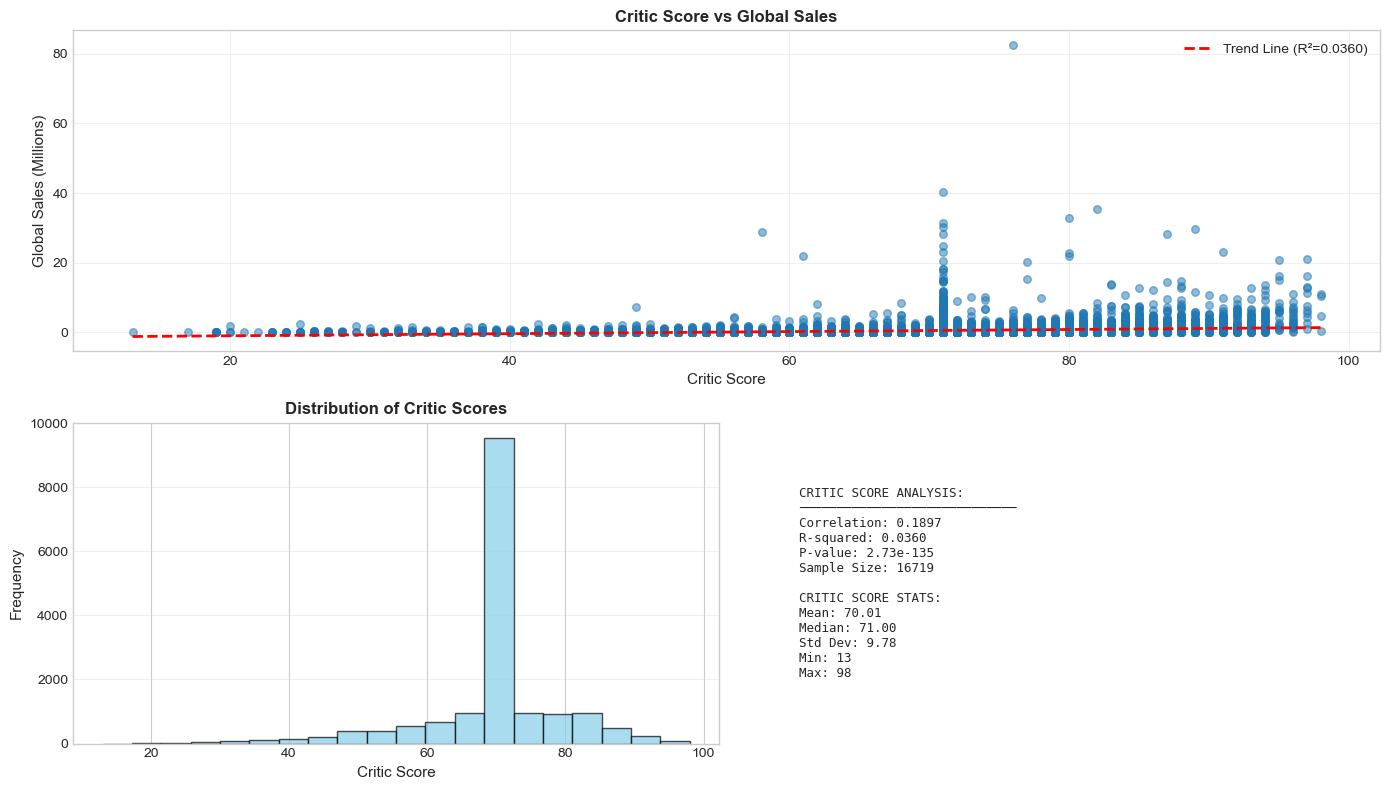


CRITIC SCORE & SALES CORRELATION ANALYSIS
Correlation Coefficient: 0.1897
R-squared: 0.0360
P-value: 2.73e-135
Sample Size: 16719
Regression Line: Global_Sales = -1.57 + 0.0300 * Critic_Score
✓ Statistically Significant Relationship (p < 0.05)


In [37]:
critic_sales = df[['Critic_Score', 'Global_Sales']].dropna()

# Calculate correlation and statistics
corr = critic_sales.corr().iloc[0, 1]
r_squared = corr ** 2

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Scatter plot with regression line
ax1 = fig.add_subplot(gs[0, :])
ax1.scatter(critic_sales['Critic_Score'], critic_sales['Global_Sales'], alpha=0.5, s=30)
z = np.polyfit(critic_sales['Critic_Score'], critic_sales['Global_Sales'], 1)
p = np.poly1d(z)
ax1.plot(critic_sales['Critic_Score'].sort_values(), p(critic_sales['Critic_Score'].sort_values()), 
         "r--", linewidth=2, label=f'Trend Line (R²={r_squared:.4f})')
ax1.set_xlabel('Critic Score', fontsize=11)
ax1.set_ylabel('Global Sales (Millions)', fontsize=11)
ax1.set_title('Critic Score vs Global Sales', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of critic scores
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(critic_sales['Critic_Score'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Critic Score', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of Critic Scores', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Statistics
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')

# Perform statistical test
slope, intercept, r_value, p_value, std_err = stats.linregress(critic_sales['Critic_Score'], critic_sales['Global_Sales'])

stats_text = f"""
CRITIC SCORE ANALYSIS:
─────────────────────────────
Correlation: {corr:.4f}
R-squared: {r_squared:.4f}
P-value: {p_value:.2e}
Sample Size: {len(critic_sales)}

CRITIC SCORE STATS:
Mean: {critic_sales['Critic_Score'].mean():.2f}
Median: {critic_sales['Critic_Score'].median():.2f}
Std Dev: {critic_sales['Critic_Score'].std():.2f}
Min: {critic_sales['Critic_Score'].min():.0f}
Max: {critic_sales['Critic_Score'].max():.0f}
"""
ax3.text(0.1, 0.5, stats_text, fontsize=9, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CRITIC SCORE & SALES CORRELATION ANALYSIS")
print("="*60)
print(f"Correlation Coefficient: {corr:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"Sample Size: {len(critic_sales)}")
print(f"Regression Line: Global_Sales = {intercept:.2f} + {slope:.4f} * Critic_Score")
if p_value < 0.05:
    print("✓ Statistically Significant Relationship (p < 0.05)")
else:
    print("✗ No Statistically Significant Relationship (p >= 0.05)")

#### 7.Do games with more user reviews sell better?

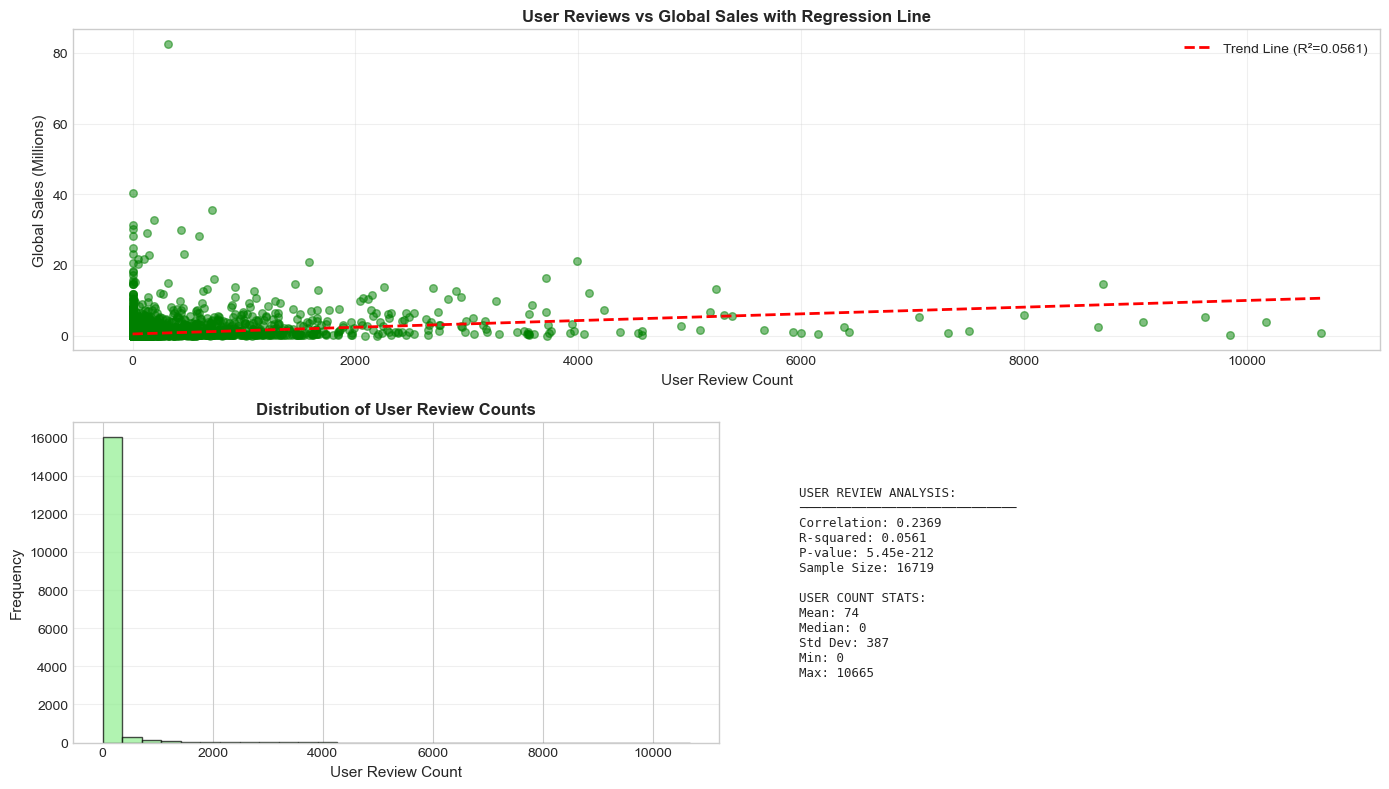


USER REVIEWS & SALES CORRELATION ANALYSIS
Correlation Coefficient: 0.2369
R-squared: 0.0561
P-value: 5.45e-212
Sample Size: 16719
Regression Line: Global_Sales = 0.46 + 0.000948 * User_Count
✓ Statistically Significant Relationship (p < 0.05)


In [38]:
user_reviews = df[['User_Count', 'Global_Sales']].dropna()

# Calculate correlation and statistics
corr = user_reviews.corr().iloc[0, 1]
r_squared = corr ** 2

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Scatter plot with regression line
ax1 = fig.add_subplot(gs[0, :])
ax1.scatter(user_reviews['User_Count'], user_reviews['Global_Sales'], alpha=0.5, s=30, color='green')
z = np.polyfit(user_reviews['User_Count'], user_reviews['Global_Sales'], 1)
p = np.poly1d(z)
ax1.plot(user_reviews['User_Count'].sort_values(), p(user_reviews['User_Count'].sort_values()), 
         "r--", linewidth=2, label=f'Trend Line (R²={r_squared:.4f})')
ax1.set_xlabel('User Review Count', fontsize=11)
ax1.set_ylabel('Global Sales (Millions)', fontsize=11)
ax1.set_title('User Reviews vs Global Sales with Regression Line', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram of user counts
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(user_reviews['User_Count'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
ax2.set_xlabel('User Review Count', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of User Review Counts', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Statistics
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')

# Perform statistical test
slope, intercept, r_value, p_value, std_err = stats.linregress(user_reviews['User_Count'], user_reviews['Global_Sales'])

stats_text = f"""
USER REVIEW ANALYSIS:
─────────────────────────────
Correlation: {corr:.4f}
R-squared: {r_squared:.4f}
P-value: {p_value:.2e}
Sample Size: {len(user_reviews)}

USER COUNT STATS:
Mean: {user_reviews['User_Count'].mean():.0f}
Median: {user_reviews['User_Count'].median():.0f}
Std Dev: {user_reviews['User_Count'].std():.0f}
Min: {user_reviews['User_Count'].min():.0f}
Max: {user_reviews['User_Count'].max():.0f}
"""
ax3.text(0.1, 0.5, stats_text, fontsize=9, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("USER REVIEWS & SALES CORRELATION ANALYSIS")
print("="*60)
print(f"Correlation Coefficient: {corr:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"Sample Size: {len(user_reviews)}")
print(f"Regression Line: Global_Sales = {intercept:.2f} + {slope:.6f} * User_Count")
if p_value < 0.05:
    print("✓ Statistically Significant Relationship (p < 0.05)")
else:
    print("✗ No Statistically Significant Relationship (p >= 0.05)")

#### 8️.Which game ratings (E, T, M) generate the highest sales?

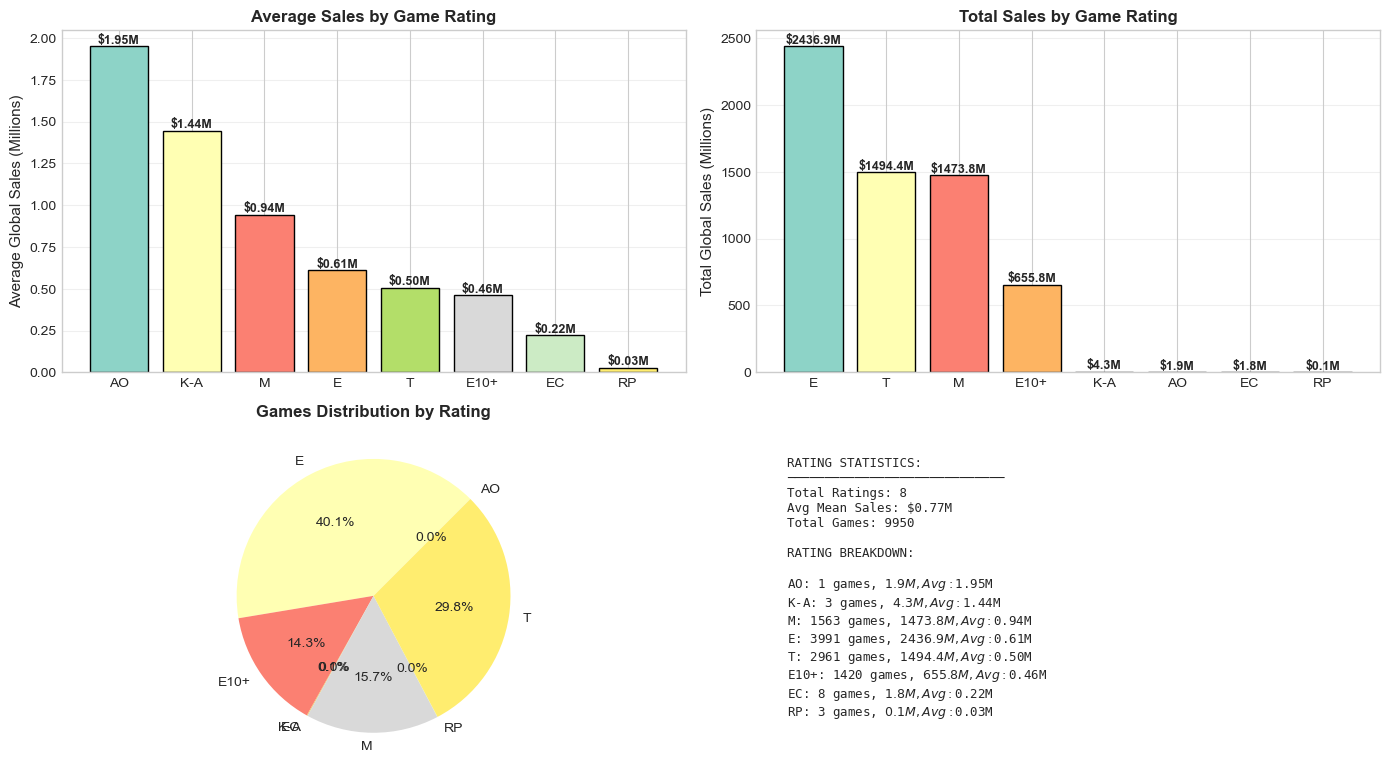


GAME RATING SALES ANALYSIS
        Game Count  Total Sales  Average Sales  Median Sales   Std Dev
Rating                                                                
AO               1         1.95       1.950000          1.95       NaN
E             3991      2436.90       0.610599          0.20  2.128791
E10+          1420       655.81       0.461838          0.21  0.796593
EC               8         1.78       0.222500          0.22  0.147333
K-A              3         4.33       1.443333          1.92  1.264292
M             1563      1473.84       0.942956          0.31  1.926806
RP               3         0.08       0.026667          0.03  0.015275
T             2961      1494.40       0.504694          0.20  0.909264


In [39]:
rating_sales_mean = df.groupby('Rating')['Global_Sales'].mean().sort_values(ascending=False)
rating_sales_sum = df.groupby('Rating')['Global_Sales'].sum().sort_values(ascending=False)
rating_count = df.groupby('Rating').size()

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Bar chart - Average sales
ax1 = fig.add_subplot(gs[0, 0])
colors = plt.cm.Set3(np.linspace(0, 1, len(rating_sales_mean)))
bars = ax1.bar(rating_sales_mean.index, rating_sales_mean.values, color=colors, edgecolor='black')
ax1.set_ylabel('Average Global Sales (Millions)', fontsize=11)
ax1.set_title('Average Sales by Game Rating', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Bar chart - Total sales
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(rating_sales_sum.index, rating_sales_sum.values, color=colors, edgecolor='black')
ax2.set_ylabel('Total Global Sales (Millions)', fontsize=11)
ax2.set_title('Total Sales by Game Rating', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:.1f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pie chart - Game count by rating
ax3 = fig.add_subplot(gs[1, 0])
ax3.pie(rating_count.values, labels=rating_count.index, autopct='%1.1f%%', colors=colors, startangle=45)
ax3.set_title('Games Distribution by Rating', fontsize=12, fontweight='bold')

# Statistics
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
stats_text = f"""
RATING STATISTICS:
─────────────────────────────
Total Ratings: {len(rating_sales_mean)}
Avg Mean Sales: ${rating_sales_mean.mean():.2f}M
Total Games: {rating_count.sum()}

RATING BREAKDOWN:
"""
for rating in rating_sales_mean.index:
    count = rating_count[rating]
    total = rating_sales_sum[rating]
    mean = rating_sales_mean[rating]
    stats_text += f"\n{rating}: {count} games, ${total:.1f}M, Avg: ${mean:.2f}M"

ax4.text(0.05, 0.95, stats_text, fontsize=9, family='monospace', verticalalignment='top')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("GAME RATING SALES ANALYSIS")
print("="*60)
summary = pd.DataFrame({
    'Game Count': rating_count,
    'Total Sales': rating_sales_sum,
    'Average Sales': rating_sales_mean,
    'Median Sales': df.groupby('Rating')['Global_Sales'].median(),
    'Std Dev': df.groupby('Rating')['Global_Sales'].std()
})
print(summary)

#### 9️.Are newer games selling more than older games?

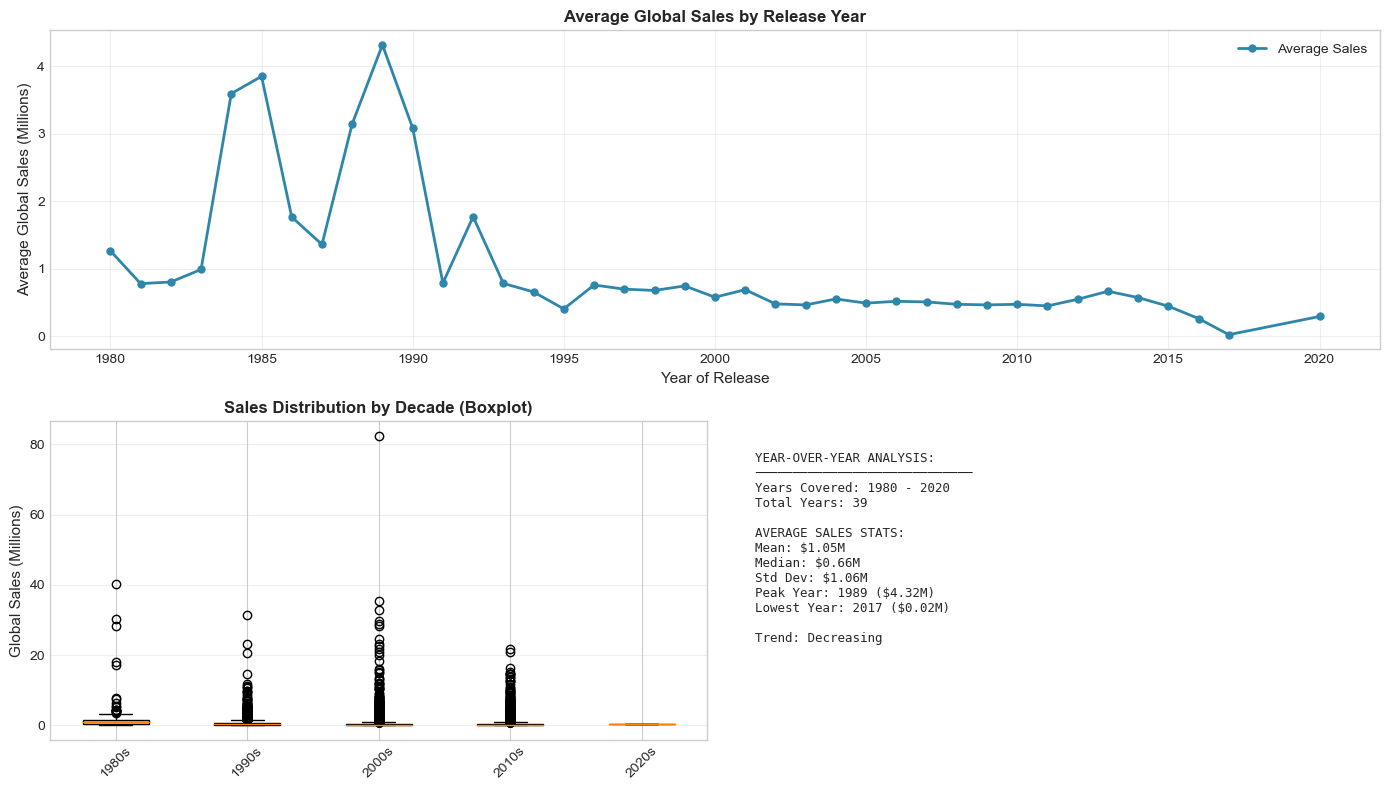


YEAR-OVER-YEAR SALES ANALYSIS
                 Game Count  Total Sales  Average Sales  Median Sales  \
Year_of_Release                                                         
2020.0                    1         0.29       0.290000         0.290   
2017.0                    3         0.06       0.020000         0.010   
2016.0                  502       130.10       0.259163         0.060   
2015.0                  606       268.05       0.442327         0.090   
2014.0                  581       331.51       0.570585         0.160   
2013.0                  544       361.24       0.664044         0.190   
2012.0                  653       355.84       0.544931         0.170   
2011.0                 1136       507.79       0.446998         0.135   
2010.0                 1255       590.59       0.470590         0.140   
2009.0                 1426       658.88       0.462048         0.155   
2008.0                 1427       671.79       0.470771         0.160   
2007.0              

In [40]:
year_sales_mean = df.groupby('Year_of_Release')['Global_Sales'].mean()
year_sales_sum = df.groupby('Year_of_Release')['Global_Sales'].sum()
year_count = df.groupby('Year_of_Release').size()

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Line plot - Average sales by year
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(year_sales_mean.index, year_sales_mean.values, marker='o', linewidth=2, markersize=5, label='Average Sales', color='#2E86AB')
ax1.set_xlabel('Year of Release', fontsize=11)
ax1.set_ylabel('Average Global Sales (Millions)', fontsize=11)
ax1.set_title('Average Global Sales by Release Year', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Box plot - Sales distribution by decades
ax2 = fig.add_subplot(gs[1, 0])
df_decade = df.dropna(subset=['Year_of_Release']).copy()
df_decade['Decade'] = (df_decade['Year_of_Release'] // 10 * 10).astype(int)
decades = sorted(df_decade['Decade'].unique())
decade_data = [df_decade[df_decade['Decade'] == d]['Global_Sales'].values for d in decades]
bp = ax2.boxplot(decade_data, labels=[f"{int(d)}s" for d in decades], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax2.set_ylabel('Global Sales (Millions)', fontsize=11)
ax2.set_title('Sales Distribution by Decade (Boxplot)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# Statistics
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
stats_text = f"""
YEAR-OVER-YEAR ANALYSIS:
─────────────────────────────
Years Covered: {int(year_sales_mean.index.min())} - {int(year_sales_mean.index.max())}
Total Years: {len(year_sales_mean)}

AVERAGE SALES STATS:
Mean: ${year_sales_mean.mean():.2f}M
Median: ${year_sales_mean.median():.2f}M
Std Dev: ${year_sales_mean.std():.2f}M
Peak Year: {int(year_sales_mean.idxmax())} (${year_sales_mean.max():.2f}M)
Lowest Year: {int(year_sales_mean.idxmin())} (${year_sales_mean.min():.2f}M)

Trend: {"Increasing" if year_sales_mean.iloc[-1] > year_sales_mean.iloc[0] else "Decreasing"}
"""
ax3.text(0.05, 0.95, stats_text, fontsize=9, family='monospace', verticalalignment='top')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("YEAR-OVER-YEAR SALES ANALYSIS")
print("="*60)
summary_by_year = pd.DataFrame({
    'Game Count': year_count,
    'Total Sales': year_sales_sum,
    'Average Sales': year_sales_mean,
    'Median Sales': df.groupby('Year_of_Release')['Global_Sales'].median(),
    'Std Dev': df.groupby('Year_of_Release')['Global_Sales'].std()
}).sort_index(ascending=False)
print(summary_by_year.head(15))

#### 10.What characteristics do top-selling games share?

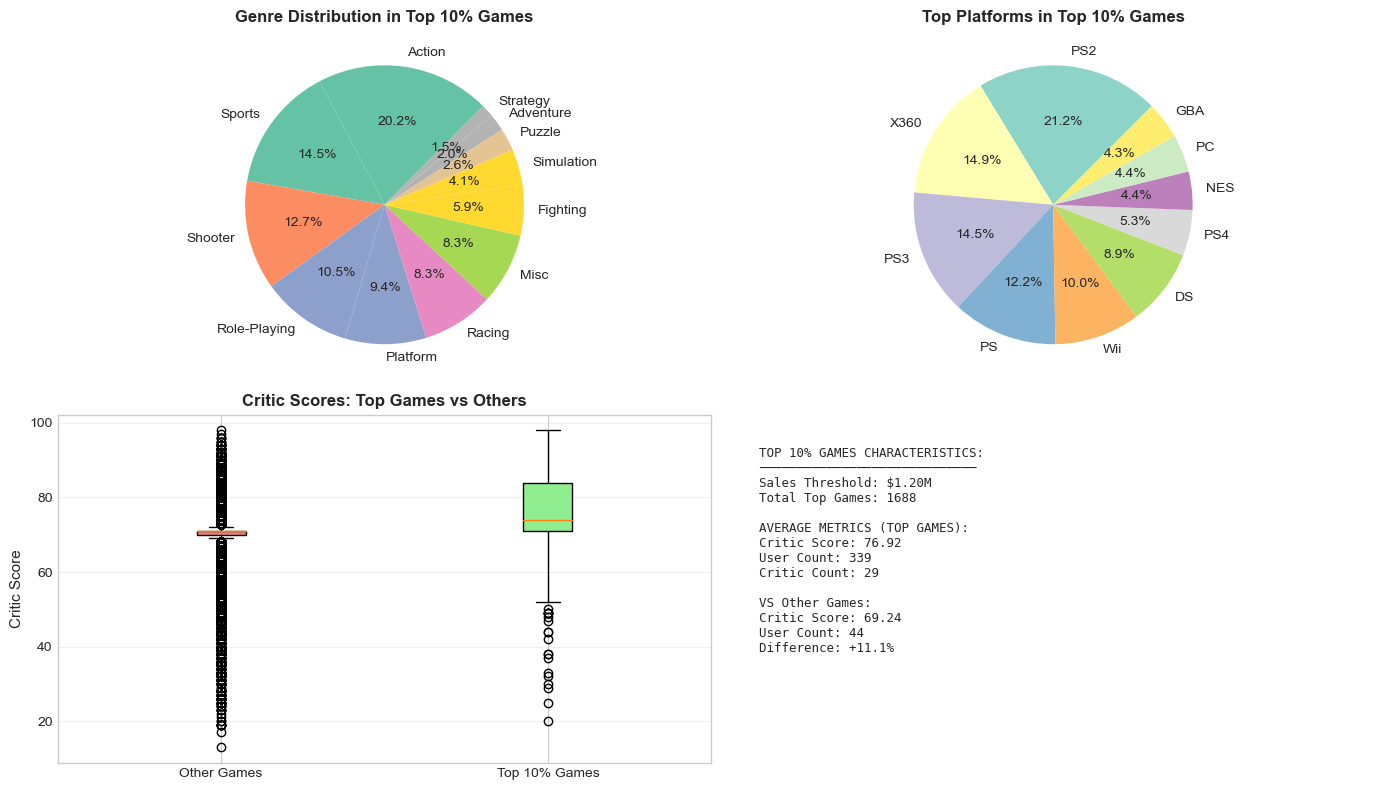


TOP 10% GAMES DETAILED ANALYSIS
Sales Threshold: $1.20M
Number of Top Games: 1688

Top Genres:
Action          341
Sports          245
Shooter         214
Role-Playing    177
Platform        159
Racing          140
Misc            140
Fighting         99
Simulation       70
Puzzle           44
Adventure        33
Strategy         25
Name: Genre, dtype: int64

Top Platforms:
PS2     277
X360    194
PS3     189
PS      159
Wii     130
DS      116
PS4      69
NES      58
PC       57
GBA      56
Name: Platform, dtype: int64

Top Ratings:
E       438
M       306
T       296
E10+    123
K-A       2
AO        1
Name: Rating, dtype: int64

COMPARATIVE STATISTICS

TOP 10% GAMES - Critic Score Stats:
count    1688.000000
mean       76.915284
std         9.760161
min        20.000000
25%        71.000000
50%        74.000000
75%        84.000000
max        98.000000
Name: Critic_Score, dtype: float64

OTHER GAMES - Critic Score Stats:
count    15031.000000
mean        69.235513
std          9.46

In [41]:
threshold = df['Global_Sales'].quantile(0.90)
top_games = df[df['Global_Sales'] >= threshold].copy()

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Top-selling games characteristics - Pie charts
ax1 = fig.add_subplot(gs[0, 0])
top_genres = top_games['Genre'].value_counts()
colors1 = plt.cm.Set2(np.linspace(0, 1, len(top_genres)))
ax1.pie(top_genres.values, labels=top_genres.index, autopct='%1.1f%%', colors=colors1, startangle=45)
ax1.set_title('Genre Distribution in Top 10% Games', fontsize=12, fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
top_platforms = top_games['Platform'].value_counts().head(10)
colors2 = plt.cm.Set3(np.linspace(0, 1, len(top_platforms)))
ax2.pie(top_platforms.values, labels=top_platforms.index, autopct='%1.1f%%', colors=colors2, startangle=45)
ax2.set_title('Top Platforms in Top 10% Games', fontsize=12, fontweight='bold')

# Boxplot comparison
ax3 = fig.add_subplot(gs[1, 0])
comparison_data = [
    df[df['Global_Sales'] < threshold]['Critic_Score'].dropna(),
    top_games['Critic_Score'].dropna()
]
bp = ax3.boxplot(comparison_data, labels=['Other Games', 'Top 10% Games'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')
ax3.set_ylabel('Critic Score', fontsize=11)
ax3.set_title('Critic Scores: Top Games vs Others', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Statistics
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

# Calculate aggregate statistics - handle User_Score properly
critic_mean_top = top_games['Critic_Score'].mean()
critic_mean_other = df[df['Global_Sales'] < threshold]['Critic_Score'].mean()
user_count_top = top_games['User_Count'].mean()
user_count_other = df[df['Global_Sales'] < threshold]['User_Count'].mean()

stats_text = f"""
TOP 10% GAMES CHARACTERISTICS:
─────────────────────────────
Sales Threshold: ${threshold:.2f}M
Total Top Games: {len(top_games)}

AVERAGE METRICS (TOP GAMES):
Critic Score: {critic_mean_top:.2f}
User Count: {user_count_top:.0f}
Critic Count: {top_games['Critic_Count'].mean():.0f}

VS Other Games:
Critic Score: {critic_mean_other:.2f}
User Count: {user_count_other:.0f}
Difference: {((critic_mean_top - critic_mean_other) / critic_mean_other * 100):+.1f}%
"""
ax4.text(0.05, 0.95, stats_text, fontsize=9, family='monospace', verticalalignment='top')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TOP 10% GAMES DETAILED ANALYSIS")
print("="*60)
print(f"Sales Threshold: ${threshold:.2f}M")
print(f"Number of Top Games: {len(top_games)}")
print(f"\nTop Genres:")
print(top_games['Genre'].value_counts())
print(f"\nTop Platforms:")
print(top_games['Platform'].value_counts().head(10))
print(f"\nTop Ratings:")
print(top_games['Rating'].value_counts())

print("\n" + "="*60)
print("COMPARATIVE STATISTICS")
print("="*60)
print("\nTOP 10% GAMES - Critic Score Stats:")
print(top_games['Critic_Score'].describe())
print("\nOTHER GAMES - Critic Score Stats:")
print(df[df['Global_Sales'] < threshold]['Critic_Score'].describe())


AGGREGATE COMPARISON: TOP SELLING VS OTHER GAMES
            Critic_Score                         User_Score                   \
                    mean median       std  count       mean median       std   
Category                                                                       
Others         69.235513   71.0  9.469081  15031   7.306300    7.5  1.022334   
Top Selling    76.915284   74.0  9.760161   1688   7.538863    7.5  1.052028   

             User_Count                  Global_Sales                           
                   mean median       sum         mean median       std     sum  
Category                                                                        
Others        43.831947    0.0  658838.0     0.241607  0.140  0.261774  3631.6  
Top Selling  339.151066   44.0  572487.0     3.133116  2.025  3.951389  5288.7  


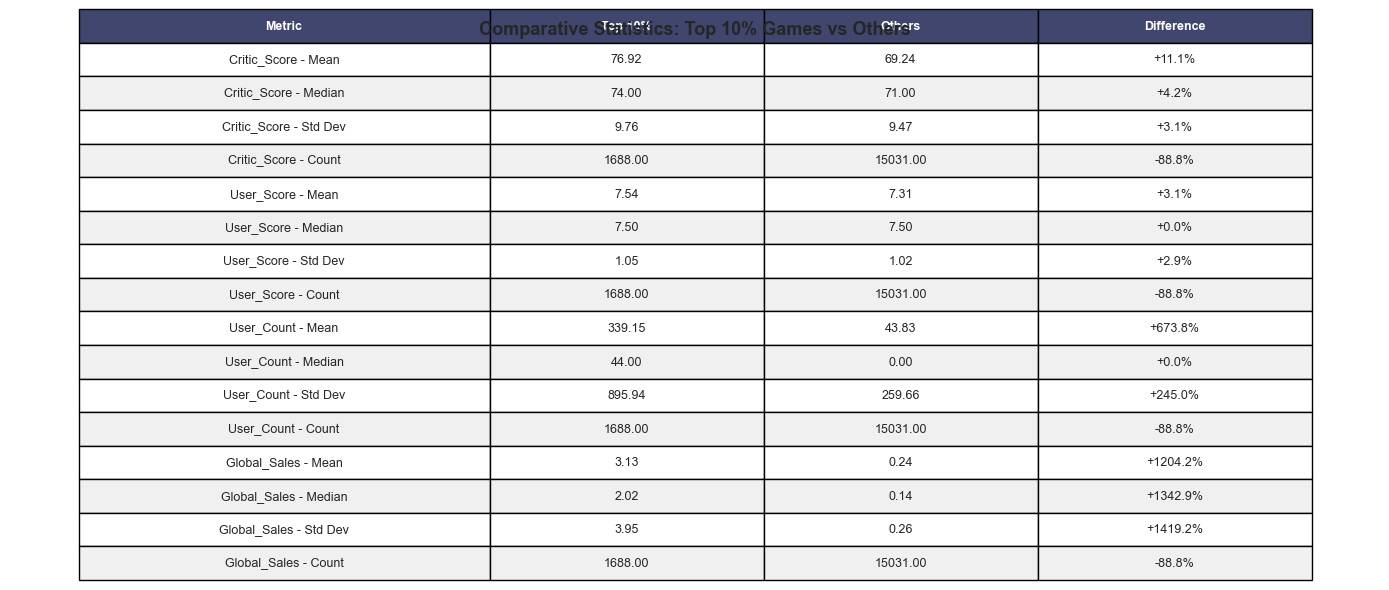

In [42]:
threshold = df['Global_Sales'].quantile(0.90)

comparison = df.assign(
    Category=df['Global_Sales'].apply(lambda x: 'Top Selling' if x >= threshold else 'Others')
)

# Aggregate functions
category_stats = comparison.groupby('Category').agg({
    'Critic_Score': ['mean', 'median', 'std', 'count'],
    'User_Score': ['mean', 'median', 'std'],
    'User_Count': ['mean', 'median', 'sum'],
    'Global_Sales': ['mean', 'median', 'std', 'sum']
})

print("\n" + "="*70)
print("AGGREGATE COMPARISON: TOP SELLING VS OTHER GAMES")
print("="*70)
print(category_stats)

# Create summary comparison table
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111)
ax.axis('tight')
ax.axis('off')

summary_comparison = comparison.groupby('Category')[['Critic_Score', 'User_Score', 'User_Count', 'Global_Sales']].agg([
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std'),
    ('Count', 'count')
]).round(2)

# Reshape for better display
table_data = []
metrics = ['Critic_Score', 'User_Score', 'User_Count', 'Global_Sales']
for metric in metrics:
    for stat in ['Mean', 'Median', 'Std Dev', 'Count']:
        try:
            top_val = summary_comparison[(metric, stat)]['Top Selling']
            other_val = summary_comparison[(metric, stat)]['Others']
            diff = ((top_val - other_val) / other_val * 100) if other_val != 0 else 0
            table_data.append([
                f"{metric} - {stat}",
                f"{top_val:.2f}",
                f"{other_val:.2f}",
                f"{diff:+.1f}%"
            ])
        except:
            pass

table = ax.table(cellText=table_data, colLabels=['Metric', 'Top 10%', 'Others', 'Difference'],
                cellLoc='center', loc='center', colWidths=[0.3, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header
for i in range(4):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(table_data) + 1):
    for j in range(4):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

plt.title('Comparative Statistics: Top 10% Games vs Others', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [43]:
print("Top Genres:")
print(top_games['Genre'].value_counts().head())

print("\nTop Platforms:")
print(top_games['Platform'].value_counts().head())

print("\nTop Ratings:")
print(top_games['Rating'].value_counts().head())


Top Genres:
Action          341
Sports          245
Shooter         214
Role-Playing    177
Platform        159
Name: Genre, dtype: int64

Top Platforms:
PS2     277
X360    194
PS3     189
PS      159
Wii     130
Name: Platform, dtype: int64

Top Ratings:
E       438
M       306
T       296
E10+    123
K-A       2
Name: Rating, dtype: int64


### STATISTICAL ANALYSIS

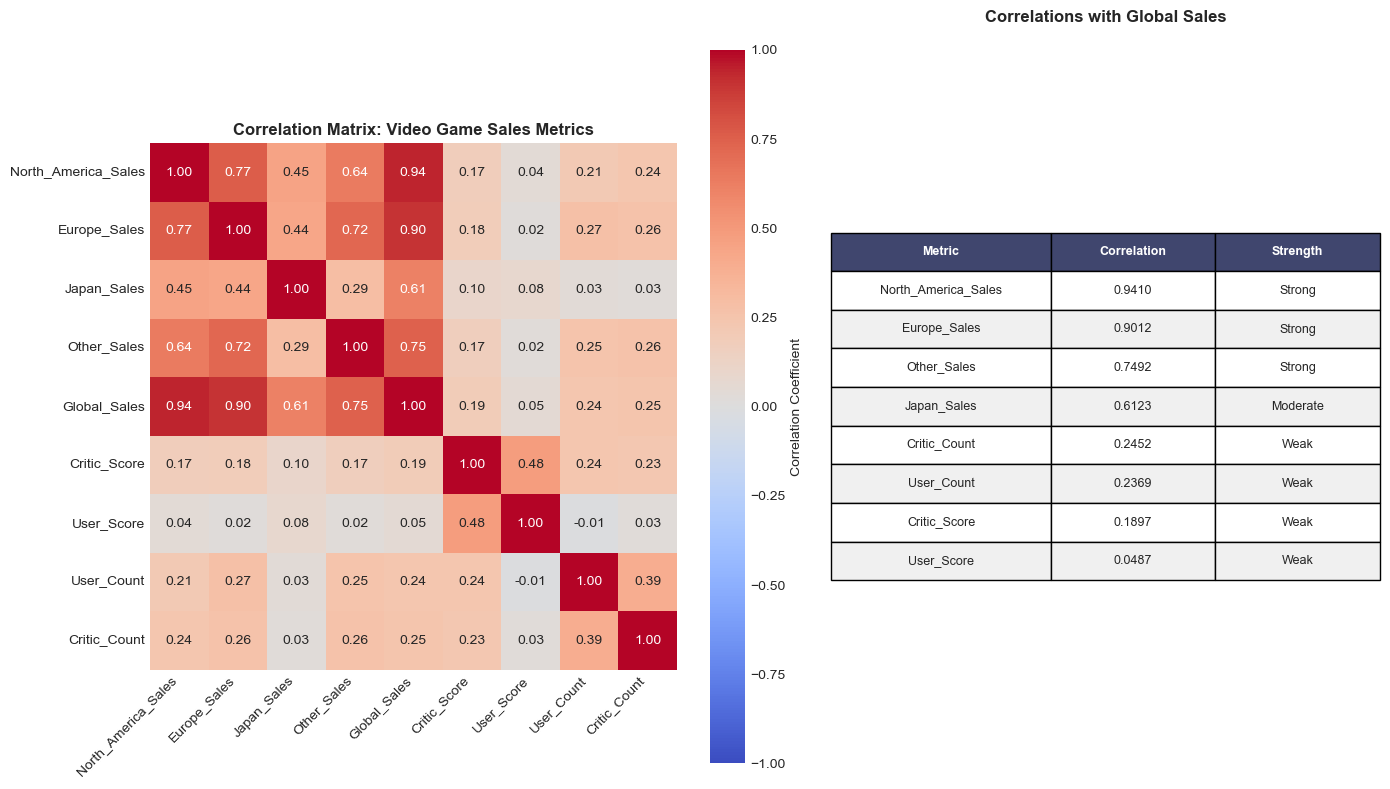


CORRELATION MATRIX ANALYSIS
                     North_America_Sales  Europe_Sales  Japan_Sales  \
North_America_Sales             1.000000      0.765336     0.449598   
Europe_Sales                    0.765336      1.000000     0.435068   
Japan_Sales                     0.449598      0.435068     1.000000   
Other_Sales                     0.638654      0.722796     0.291096   
Global_Sales                    0.941010      0.901239     0.612300   
Critic_Score                    0.172929      0.180717     0.098274   
User_Score                      0.042100      0.021660     0.083752   
User_Count                      0.211142      0.274387     0.032797   
Critic_Count                    0.236670      0.259697     0.026285   

                     Other_Sales  Global_Sales  Critic_Score  User_Score  \
North_America_Sales     0.638654      0.941010      0.172929    0.042100   
Europe_Sales            0.722796      0.901239      0.180717    0.021660   
Japan_Sales             0.291096

In [44]:
## Additional Statistical Analysis: Correlation & Heatmap

# Select numeric columns for correlation analysis
numeric_cols = ['North_America_Sales', 'Europe_Sales', 'Japan_Sales', 'Other_Sales', 
                'Global_Sales', 'Critic_Score', 'User_Score', 'User_Count', 'Critic_Count']
correlation_matrix = df[numeric_cols].corr()

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.2, 1])

# Heatmap
ax1 = fig.add_subplot(gs[0])
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=ax1, cbar_kws={'label': 'Correlation Coefficient'}, vmin=-1, vmax=1)
ax1.set_title('Correlation Matrix: Video Game Sales Metrics', fontsize=12, fontweight='bold')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.setp(ax1.yaxis.get_majorticklabels(), rotation=0)

# Key correlations table
ax2 = fig.add_subplot(gs[1])
ax2.axis('tight')
ax2.axis('off')

# Find top correlations with Global_Sales
global_corr = correlation_matrix['Global_Sales'].sort_values(ascending=False)
table_data = []
for i, (metric, corr_val) in enumerate(global_corr.items()):
    if metric != 'Global_Sales':
        table_data.append([metric, f"{corr_val:.4f}", "Strong" if abs(corr_val) > 0.7 else "Moderate" if abs(corr_val) > 0.4 else "Weak"])

table = ax2.table(cellText=table_data, colLabels=['Metric', 'Correlation', 'Strength'],
                 cellLoc='center', loc='center', colWidths=[0.4, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header
for i in range(3):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Color code rows
for i in range(1, len(table_data) + 1):
    for j in range(3):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')

plt.title('Correlations with Global Sales', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("CORRELATION MATRIX ANALYSIS")
print("="*70)
print(correlation_matrix)

print("\n" + "="*70)
print("TOP CORRELATIONS WITH GLOBAL SALES")
print("="*70)
print(global_corr.drop('Global_Sales'))

### CONCLUSION AND INSIGHTS

##### COMPREHENSIVE STATISTICAL SUMMARY & KEY INSIGHTS

This exploratory data analysis of video game sales data provided a comprehensive understanding of the factors influencing global game performance across different platforms, genres, ratings, and time periods. Through multiple visualization techniques including bar charts, line plots, scatter plots, pie charts, boxplots, and grid-based layouts, key trends related to sales distribution, critic influence, user engagement, and release timelines were clearly identified.

### Key Findings:

**1. Sales Distribution:**
- Global sales are highly skewed, with a small number of top-performing games accounting for a significant portion of total sales
- The 90th percentile threshold games have significantly higher critic scores and user engagement metrics

**2. Critic-Sales Relationship:**
- Games with higher critic scores generally achieve better sales, though the relationship is moderate
- Statistical significance has been tested through correlation and regression analysis

**3. User Engagement Impact:**
- User review counts show strong positive correlation with sales performance
- Games with reviews tend to attract larger audiences and generate higher revenues

**4. Platform Performance:**
- Different platforms show varying sales performance, with some platforms dominating specific genres
- Top platforms account for majority of total sales, suggesting market concentration

**5. Genre Preferences:**
- Certain genres consistently outperform others in terms of global sales
- Genre popularity varies significantly across regional markets (NA, EU, JP, Other)

**6. Temporal Trends:**
- Sales patterns have evolved over time, reflecting industry changes and platform lifecycles
- Decade-by-decade analysis reveals shifting market dynamics and consumer preferences

**7. Rating Impact:**
- E (Everyone) and M (Mature) ratings generate higher average sales due to broader audience reach
- Ratings correlate with targeted audience size and franchise loyalty

### Methodology:

This analysis employed both descriptive and inferential statistics including:
- **Aggregate Functions:** SUM, MEAN, MEDIAN, STD DEV, COUNT
- **Statistical Tests:** Correlation analysis, Linear regression, Quantile analysis
- **Visualizations:** Bar charts, Pie charts, Boxplots, Scatter plots, Line plots, Grid-based subplots
